<a href="https://colab.research.google.com/github/mmm10138/Machine-Learning/blob/main/Euler_Method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook is about some "classical" scientific computing methods.

# Euler methods for ODEs

## Explicit

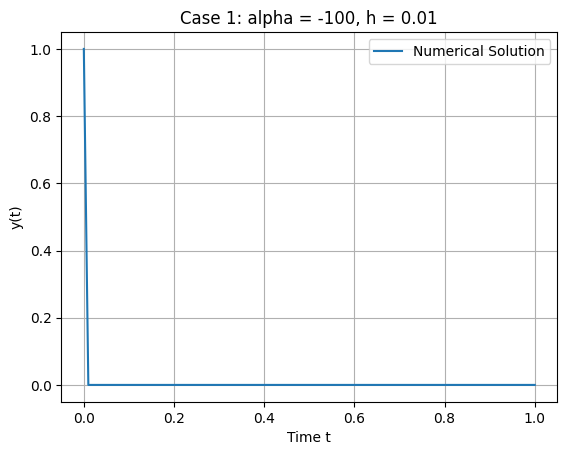

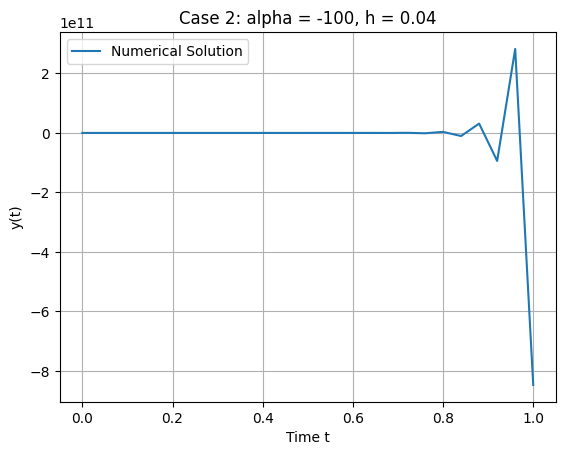

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Euler method to solve y'(t) = alpha * y(t)
def euler_method(t0, t1, alpha, h, y0):
    # Time steps
    t_values = np.arange(t0, t1 + h, h)
    y_values = np.zeros_like(t_values)

    # Initial condition
    y_values[0] = y0

    # Euler time-stepping
    for i in range(1, len(t_values)):
        y_values[i] = y_values[i-1]+h*alpha*y_values[i-1]

    return t_values, y_values

# Function to plot results
def plot_solution(t_values, y_values, title):
    plt.plot(t_values, y_values, label='Numerical Solution')
    plt.xlabel('Time t')
    plt.ylabel('y(t)')
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

# Test case 1: t0=0, t1=1, alpha=-100, h=0.01
t0, t1, alpha, h, y0 = 0, 1, -100, 0.01, 1
t_values, y_values = euler_method(t0, t1, alpha, h, y0)
plot_solution(t_values, y_values, "Case 1: alpha = -100, h = 0.01")

# Test case 2: t0=0, t1=1, alpha=-100, h=0.04
t0, t1, alpha, h, y0 = 0, 1, -100, 0.04, 1
t_values, y_values = euler_method(t0, t1, alpha, h, y0)
plot_solution(t_values, y_values, "Case 2: alpha = -100, h = 0.04")

We observe that test case 1 is stable (and the values converge very quickly to $0$ as time increases) but test case 2 is unstable, as seen by the large values of the y-axis.

## Implicit

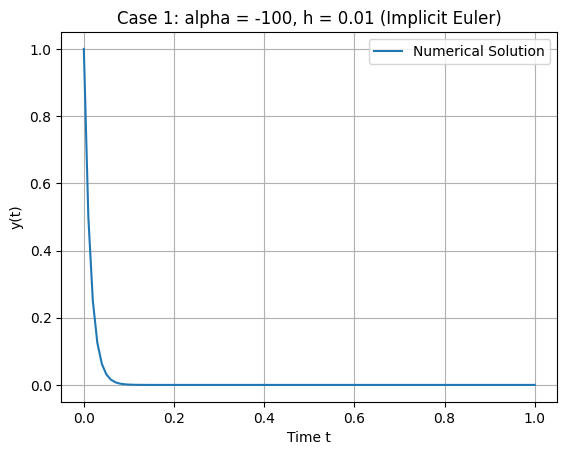

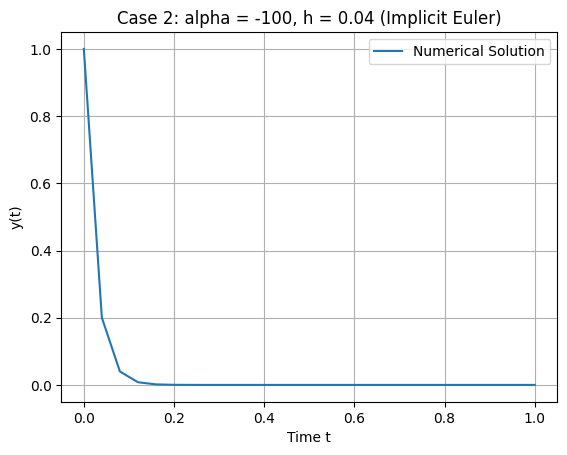

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Implicit Euler method to solve y'(t) = alpha * y(t)
def implicit_euler_method(t0, t1, alpha, h, y0):
    # Time steps
    t_values = np.arange(t0, t1 + h, h)
    y_values = np.zeros_like(t_values)

    # Initial condition
    y_values[0] = y0

    # Implicit Euler time-stepping
    for i in range(1, len(t_values)):
        # Implicit update rule: y_{n+1} = y_n / (1 - h * alpha)
        y_values[i] = y_values[i-1]/(1-h*alpha)

    return t_values, y_values

# Function to plot results
def plot_solution(t_values, y_values, title):
    plt.plot(t_values, y_values, label='Numerical Solution')
    plt.xlabel('Time t')
    plt.ylabel('y(t)')
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

# Test case 1: t0=0, t1=1, alpha=-100, h=0.01
t0, t1, alpha, h, y0 = 0, 1, -100, 0.01, 1
t_values, y_values = implicit_euler_method(t0, t1, alpha, h, y0)
plot_solution(t_values, y_values, "Case 1: alpha = -100, h = 0.01 (Implicit Euler)")

# Test case 2: t0=0, t1=1, alpha=-100, h=0.04
t0, t1, alpha, h, y0 = 0, 1, -100, 0.04, 1
t_values, y_values = implicit_euler_method(t0, t1, alpha, h, y0)
plot_solution(t_values, y_values, "Case 2: alpha = -100, h = 0.04 (Implicit Euler)")


We observe that the method is not unstable in these two cases.

However we note that the results look different than the ones obtained with the explicit method.

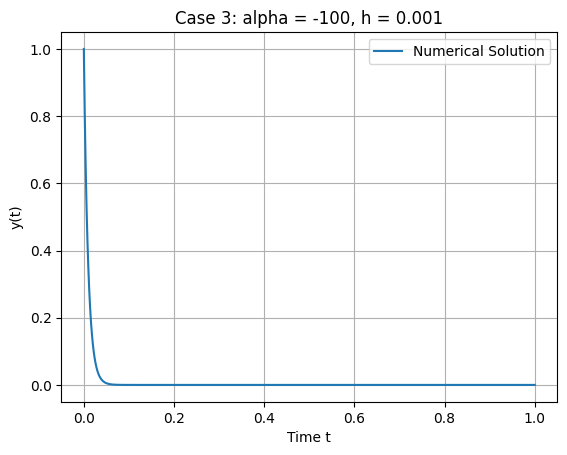

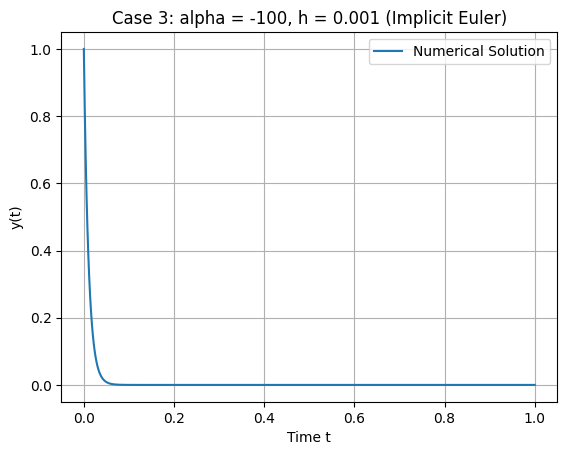

In [12]:
# Comparison of explicit and implicit Euler methods

# Test case 3: t0=0, t1=1, alpha=-100, h=0.001
t0, t1, alpha, h, y0 = 0, 1, -100, 0.001, 1
# Explicit method
t_values, y_values = euler_method(t0, t1, alpha, h, y0)
plot_solution(t_values, y_values, "Case 3: alpha = -100, h = 0.001")
# Implicit method
t_values, y_values = implicit_euler_method(t0, t1, alpha, h, y0)
plot_solution(t_values, y_values, "Case 3: alpha = -100, h = 0.001 (Implicit Euler)")

Actually the two methods give similar results when the step size is small enough.

In [ ]:
# TODO: Plot the two solutions on the same plot and add the true solution (analytical formula)
# Try other ODEs.

Test with alpha = 100

In [ ]:
# Test case 1: t0=0, t1=1, alpha=-100, h=0.01
t0, t1, alpha, h, y0 = 0, 1.0, 10, 0.0001, 1
t_values, y_values = implicit_euler_method(t0, t1, alpha, h, y0)
plot_solution(t_values, y_values, "Case 1: alpha = -100, h = 0.01 (Implicit Euler)")

# 1D heat equation (Optional)



**Problem description**

We are solving the 1D heat equation on the domain $[0,1] \times [0,1]$ given by:

$$
  u_t = 0.5\sigma^2 u_{xx}
$$

where $u(t, x)$ represents the temperature distribution along a 1D rod over time $t$ and spatial coordinate $x$. The coefficient $\sigma = 0.15$ is a constant related to the diffusivity of the material, and $0.5\sigma^2$ represents the thermal diffusivity in the context of this equation.

The initial and boundary conditions are:

* Initial condition: The temperature distribution at time $t = 0$ is given by
$$
    u(0, x) = x(1-x) \quad \text{for } x \in [0, 1].
$$
* Boundary conditions: The temperature at both ends of the rod is held at zero for all times:
$$
    u(t, 0) = 0, \quad u(t, 1) = 0 \quad \text{for } t \geq 0.
$$

**Intuition Behind the PDE**

The heat equation is a fundamental partial differential equation that describes how heat diffuses through a given region over time. In one dimension, the heat equation takes the form:

$$
  u_t = \alpha u_{xx}
$$

where $\alpha$ is the thermal diffusivity of the material. The term $u_t$ represents the time derivative of the temperature $u$, which gives the rate of change of temperature over time. The term $u_{xx}$ represents the second spatial derivative, which gives the curvature of the temperature distribution along the rod.

Intuitively, the heat equation states that the rate of change of temperature at a point is proportional to the curvature of the temperature profile at that point. Regions with higher curvature will see faster rates of temperature change, leading to the smoothing out of temperature differences over time. This reflects the physical behavior where heat naturally flows from hotter regions to cooler ones, causing the temperature distribution to become more uniform over time.

**Intuition Behind the Boundary and Initial Conditions**

**Initial Condition**

The initial condition $u(0, x) = x(1-x)$ specifies the temperature distribution along the rod at the initial time $t = 0$. This particular distribution is parabolic, with the maximum temperature occurring at the center of the rod ($x = 0.5$) and zero temperature at the ends ($x = 0$ and $x = 1$).

This setup could represent a physical scenario where the rod was initially heated with a source concentrated in the middle, creating a temperature gradient that will then evolve according to the heat equation.

**Boundary Conditions**

The boundary conditions $u(t, 0) = 0$ and $u(t, 1) = 0$ enforce that the temperature at both ends of the rod remains zero for all times $t \geq 0$. These conditions could model a situation where the ends of the rod are kept in contact with a thermal reservoir at zero temperature (e.g., ice baths), ensuring that no matter how the internal temperature of the rod evolves, the ends will always remain at zero degrees.

These boundary conditions are physically realistic for scenarios where the ends of the rod are fixed at a constant temperature, and they ensure that over time, the temperature distribution along the rod will be influenced by these fixed end temperatures.



## With CFL condition satisfied


**Introduction**

The CFL (Courant-Friedrichs-Lewy) condition is a critical stability criterion in the numerical solution of partial differential equations (PDEs), particularly when using explicit time-stepping methods like the explicit Euler method. This condition is necessary to ensure that the numerical solution remains stable and converges to the correct solution as the computation proceeds.

**Understanding the CFL Condition**

The CFL condition can be understood as a constraint on the time step size $\Delta t$ in relation to the spatial grid size $\Delta x$ and the physical properties of the system being modeled. The condition ensures that the numerical domain of dependence includes the physical domain of dependence of the PDE.

**Application to the 1D Heat Equation**

Consider the 1D heat equation:

$$
  u_t = \alpha u_{xx},
$$

where $u(t, x)$ is the temperature distribution, $\alpha$ is the thermal diffusivity, $t$ is time, and $x$ is the spatial coordinate.

When discretizing this equation using an explicit time-stepping method such as the explicit Euler method, we approximate the time derivative and the second spatial derivative as:

$$
  \frac{u^{n+1}_i - u^n_i}{\Delta t} = \alpha \frac{u^n_{i+1} - 2u^n_i + u^n_{i-1}}{\Delta x^2}.
$$

Here, $u^n_i$ represents the numerical solution at time step $n$ and spatial point $i$.

Rearranging this equation gives us the update formula for the numerical solution:

$$
  u^{n+1}_i = u^n_i + \frac{\alpha \Delta t}{\Delta x^2} \left(u^n_{i+1} - 2u^n_i + u^n_{i-1}\right).
$$

**Derivation of the CFL Condition**

For the numerical solution to remain stable, the coefficient of the spatial term $\frac{\alpha \Delta t}{\Delta x^2}$ must be small enough. If this coefficient is too large, the numerical solution will exhibit non-physical oscillations and may eventually diverge.

The CFL condition imposes a limit on $\Delta t$ as follows:

$$
  \frac{\alpha \Delta t}{\Delta x^2} \leq \frac{1}{2},
$$

or equivalently,

$$
  \Delta t \leq \frac{\Delta x^2}{2\alpha}.
$$

This inequality ensures that the numerical method is stable, meaning that the numerical errors do not grow uncontrollably with each time step.

**Intuition Behind the CFL Condition**

The CFL condition can be interpreted physically as a requirement that the numerical time step $\Delta t$ must be small enough for information to propagate across the spatial grid in a stable manner. In the context of the heat equation, it ensures that the heat does not diffuse more rapidly than the numerical method can accurately capture.

If the time step $\Delta t$ is too large relative to the grid spacing $\Delta x$, the numerical method attempts to model heat diffusion over a larger interval of time than is accurate, leading to instability. On the other hand, if the CFL condition is satisfied, the method accurately captures the local heat diffusion, leading to a stable and convergent solution.




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# Define the PDE coefficients and parameters
Lx = 1.0  # Length of the domain
Nx = 200  # Number of spatial grid points
Dx = Lx / (Nx - 1)  # Spatial grid spacing
sigma = 0.15  # Diffusion coefficient
D = 0.5 * sigma**2  # Diffusion term in the PDE
T = 1.0  # Total simulation time (for demonstration)

# Compute the time step size based on the CFL condition
dt_cfl = 0.5 * Dx**2 / D
Nt_cfl = int(T / dt_cfl)  # Number of time steps when CFL condition is satisfied

print(f"CFL Satisfied: Time step size = {dt_cfl}, Number of time steps = {Nt_cfl}")

# Initial condition: u(0, x) = x * (1 - x)
x = np.linspace(0, Lx, Nx)
u0 = x * (1 - x)

# Function to solve the 1D heat equation using the explicit Euler method
def solve_1d_heat_eq(Nt, dt, u0):
    u_all = np.zeros((Nt, Nx))
    u_all[0] = u0

    for n in range(1, Nt):
        u_new = u_all[n-1].copy()
        for i in range(1, Nx-1):
            u_new[i] = u_all[n-1][i] + D * dt / Dx**2 * (u_all[n-1][i+1] - 2 * u_all[n-1][i] + u_all[n-1][i-1])
        u_all[n] = u_new

    return u_all

# Solve the 1D heat equation with CFL condition satisfied
u_all_cfl = solve_1d_heat_eq(Nt_cfl, dt_cfl, u0)

# Plotting function to show the evolution of the solution and a heatmap
def plot_1d_solution(u_all, dt, title_prefix=""):
    Nt = u_all.shape[0]
    time_steps = [0, Nt//4, Nt//2, 3*Nt//4, Nt-1]

    # Plot the solution at selected time steps
    fig, axes = plt.subplots(1, len(time_steps), figsize=(18, 4))
    for i, step in enumerate(time_steps):
        axes[i].plot(x, u_all[step])
        axes[i].set_title(f"{title_prefix} t = {step * dt:.3f}")
        axes[i].set_xlabel('x')
        axes[i].set_ylabel('u')

    plt.tight_layout()
    plt.show()

    # Plot heatmap with x on one axis and time on the other
    plt.figure(figsize=(10, 6))
    plt.imshow(u_all, extent=[0, Lx, 0, T], aspect='auto', cmap=cm.viridis, origin='lower')
    plt.colorbar(label='u')
    plt.xlabel('x')
    plt.ylabel('t')
    plt.title(f"{title_prefix} Heatmap")
    plt.show()

# Plot the solutions for both cases
plot_1d_solution(u_all_cfl, dt_cfl, title_prefix="CFL Satisfied")


## With CFL condition violated

In [3]:
# Choose a larger time step that violates the CFL condition
dt_no_cfl = 1.1 * dt_cfl
Nt_no_cfl = int(T / dt_no_cfl)  # Number of time steps when CFL condition is not satisfied

print(f"CFL Violated: Time step size = {dt_no_cfl}, Number of time steps = {Nt_no_cfl}")

# Solve the 1D heat equation with CFL condition violated
u_all_no_cfl = solve_1d_heat_eq(Nt_no_cfl, dt_no_cfl, u0)

# Plot the solutions for both cases
plot_1d_solution(u_all_no_cfl, dt_no_cfl, title_prefix="CFL Violated")

NameError: name 'dt_cfl' is not defined

# 2D Advection-Diffusion Equation (Optional)



**Problem Description**

We aim to solve the 2D advection-diffusion equation using a finite difference scheme. The general form of the 2D advection-diffusion equation is given by:

\begin{equation}
\frac{\partial u}{\partial t} + v_x \frac{\partial u}{\partial x} + v_y \frac{\partial u}{\partial y} = D \left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right)
\end{equation}

where:
*  $u(x, y, t)$ is the unknown concentration at position $(x, y)$ and time $t$.
*  $v_x$ and $v_y$ are the velocities in the $x$ and $y$ directions, respectively.
*  $D$ is the diffusion coefficient.



We discretize the spatial domain using a grid and advance the solution in time using an explicit Euler method.

**CFL Condition**

To ensure stability, the time step $\Delta t$ must satisfy the CFL condition:

\begin{equation}
\Delta t \leq \frac{1}{2} \left( \frac{1}{\frac{v_x}{\Delta x} + \frac{v_y}{\Delta y} + \frac{2D}{\Delta x^2} + \frac{2D}{\Delta y^2}} \right)
\end{equation}

where $\Delta x$ and $\Delta y$ are the spatial step sizes.

In [4]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# Define the PDE coefficients and parameters
Lx, Ly = 1.0, 1.0  # Domain size
Nx, Ny = 50, 50  # Number of grid points
Dx, Dy = Lx / (Nx - 1), Ly / (Ny - 1)  # Grid spacing
D = 0.01  # Diffusion coefficient
vx, vy = 1.0, 1.0  # Velocities in x and y directions
T = 1.0  # Total simulation time

# Compute the time step size based on the CFL condition
dt = 0.5 * (1.0 / (vx / Dx + vy / Dy + 2 * D / Dx**2 + 2 * D / Dy**2))
Nt = int(T / dt)  # Number of time steps

print(f"Time step size: {dt}")
print(f"Number of time steps: {Nt}")

# Initial condition: Gaussian pulse in the center
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y)
u0 = np.exp(-((X - Lx/2)**2 + (Y - Ly/2)**2) / 0.01)

# Initialize array to store the solution at all time steps
u_all = np.zeros((Nt, Nx, Ny))
u_all[0] = u0

# Solve the PDE using the explicit Euler method
for n in range(1, Nt):
    u_new = u_all[n-1].copy()
    for i in range(1, Nx-1):
        for j in range(1, Ny-1):
            u_new[i, j] = u_all[n-1][i, j] - dt * (
                vx * (u_all[n-1][i, j] - u_all[n-1][i-1, j]) / Dx +
                vy * (u_all[n-1][i, j] - u_all[n-1][i, j-1]) / Dy
            ) + dt * D * (
                (u_all[n-1][i+1, j] - 2 * u_all[n-1][i, j] + u_all[n-1][i-1, j]) / Dx**2 +
                (u_all[n-1][i, j+1] - 2 * u_all[n-1][i, j] + u_all[n-1][i, j-1]) / Dy**2
            )
    u_all[n] = u_new

Time step size: 0.0025767882910740047
Number of time steps: 388


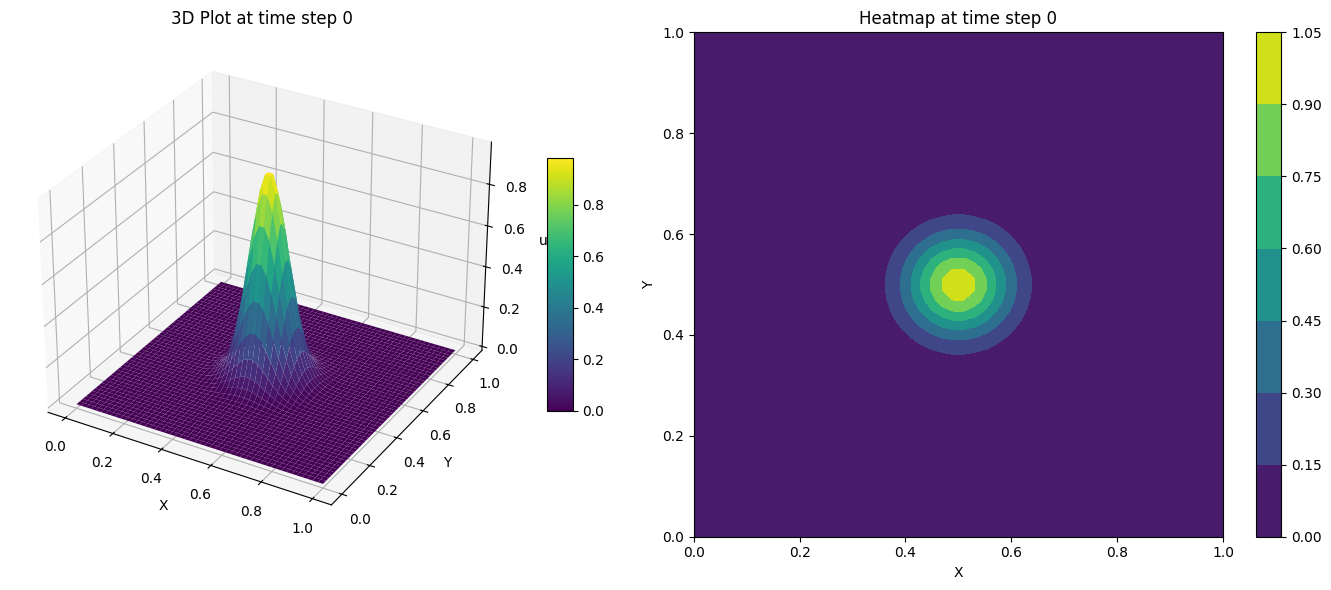

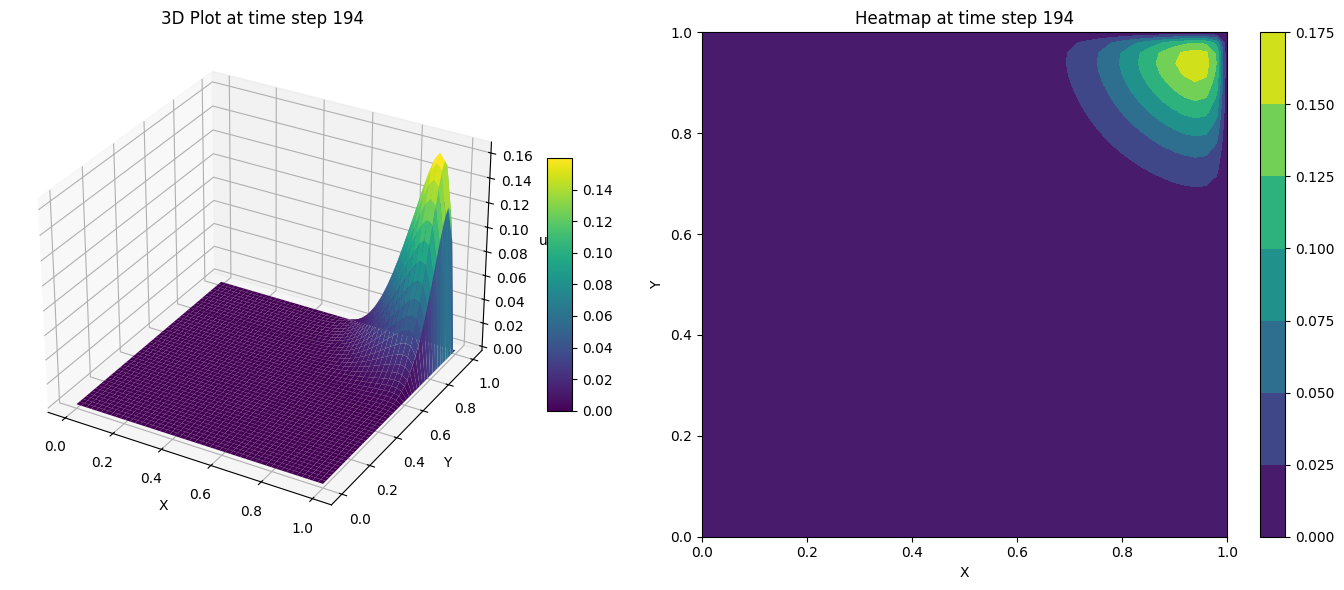

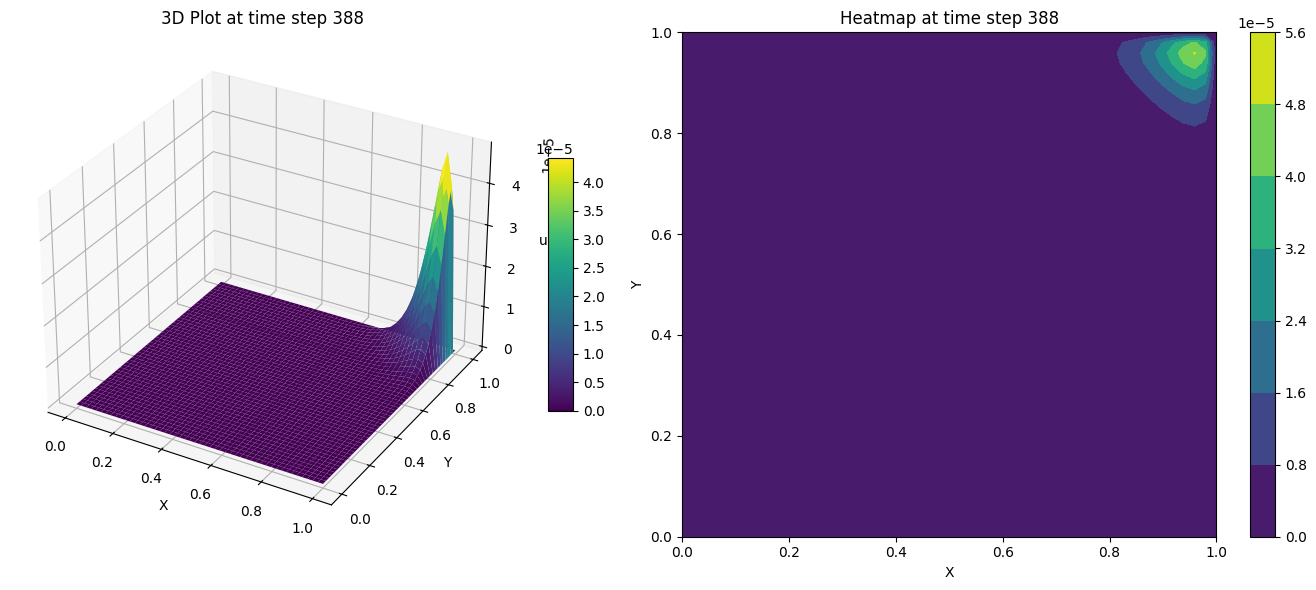

In [5]:
# Visualize the solution at any desired time step
def plot_solution(u, time_step):
    fig = plt.figure(figsize=(14, 6))

    # 3D surface plot
    ax1 = fig.add_subplot(121, projection='3d')
    surf = ax1.plot_surface(X, Y, u, cmap=cm.viridis)
    fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)  # Adjust colorbar size and aspect ratio
    ax1.set_title(f"3D Plot at time step {time_step}")
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('u')

    # Heatmap
    ax2 = fig.add_subplot(122)
    c = ax2.contourf(X, Y, u, cmap=cm.viridis)
    fig.colorbar(c, ax=ax2)
    ax2.set_title(f"Heatmap at time step {time_step}")
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')

    plt.tight_layout()
    plt.show()

# Example: Plot the solution at the initial, middle, and final time steps
plot_solution(u_all[0], 0)
plot_solution(u_all[Nt//2], Nt//2)
plot_solution(u_all[-1], Nt)